# 4. Beda kota: di mana modal mie ayam paling mahal?

Lanjutan notebook 2 dan 3. Sekarang pertanyaannya bukan soal waktu, tapi **tempat**: dengan resep yang sama, semangkuk mie ayam modal bahannya paling mahal di provinsi mana, dan paling murah di mana?

**Penting:** terigu (mie) belum ada di PIHPS, jadi angka di sini adalah biaya bahan **tanpa mie**, dan yang dihitung adalah **biaya bahan baku**, bukan harga jual.

**Data:** PIHPS Nasional (Bank Indonesia), pasar tradisional, laporan harian. Tiap provinsi diambil **rata-rata harga hari kerja September 2026** (22 hari), supaya tidak bergantung pada satu hari saja.

## Langkah 1: Muat data dan cek

Satu baris per provinsi. Harga ayam, bawang merah, dan bawang putih per kg; minyak per liter (dua merek kemasan, sama seperti notebook 2).

Provinsi yang **tidak ikut** (4 dari 34):
- Kepulauan Bangka Belitung, Maluku, dan Papua Barat: data minyak goreng belum lengkap saat diunduh.
- Maluku Utara: harga keempat bahan tidak bergerak sama sekali selama sebulan (bulat dan datar), kemungkinan data tidak diperbarui. Kalau ikut, angkanya mengotori peringkat.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

DATA = '/kaggle/input/datasets/samuelgeraldo/bedah-mie-ayam-pakai-data-bukan-sumpit/harga_30provinsi_sep2026_v2.csv'
df = pd.read_csv(DATA)

print('Jumlah provinsi:', len(df))
print('Sel kosong:', int(df.isna().sum().sum()))
df.head()

Jumlah provinsi: 30
Sel kosong: 0


,provinsi,ayam_kg,bawang_merah_kg,bawang_putih_kg,minyak_kemasan1_liter,minyak_kemasan2_liter
0,Aceh,42511.4,32906.8,35054.5,24150.0,24400.0
1,Sumatera Utara,51422.7,32756.8,35020.5,22922.7,23184.1
2,Sumatera Barat,55638.6,31727.3,34609.1,24877.3,23100.0
3,Riau,37952.3,31906.8,36036.4,23031.8,22013.6
4,Kepulauan Riau,41540.9,38584.1,29693.2,21127.3,20113.6


## Langkah 2: Resep dan biaya per porsi

Resep **sama persis dengan notebook 2** (asumsi, bukan resep asli warung), supaya hasilnya bisa dibandingkan.

Rumusnya: harga per kg (atau liter) dibagi 1000 jadi harga per gram (atau ml), lalu dikali takaran per porsi. Contoh: ayam Rp 42.000/kg → Rp 42 per gram → × 60 g = Rp 2.520 per porsi.

Minyak: ada dua merek kemasan di data, jadi dirata-rata dulu per provinsi (sama seperti notebook 2).

In [2]:
RESEP = {  # takaran per porsi (sama dengan notebook 2)
    'ayam_g': 60, 'bawang_merah_g': 10, 'bawang_putih_g': 5, 'minyak_ml': 20,
}
minyak = df[['minyak_kemasan1_liter', 'minyak_kemasan2_liter']].mean(axis=1)

biaya = pd.DataFrame({'provinsi': df['provinsi']})
biaya['ayam']          = df['ayam_kg'] * RESEP['ayam_g'] / 1000
biaya['bawang_merah']  = df['bawang_merah_kg'] * RESEP['bawang_merah_g'] / 1000
biaya['bawang_putih']  = df['bawang_putih_kg'] * RESEP['bawang_putih_g'] / 1000
biaya['minyak']        = minyak * RESEP['minyak_ml'] / 1000
biaya['total_tanpa_mie'] = biaya[['ayam', 'bawang_merah', 'bawang_putih', 'minyak']].sum(axis=1)

biaya.sort_values('total_tanpa_mie', ascending=False).round(0)

,provinsi,ayam,bawang_merah,bawang_putih,minyak,total_tanpa_mie
29,Papua,3080.0,619.0,272.0,564.0,4535.0
2,Sumatera Barat,3338.0,317.0,173.0,480.0,4308.0
1,Sumatera Utara,3085.0,328.0,175.0,461.0,4049.0
17,Nusa Tenggara Timur,3029.0,307.0,223.0,473.0,4032.0
22,Kalimantan Utara,2852.0,446.0,205.0,477.0,3980.0
6,Bengkulu,2751.0,376.0,193.0,472.0,3793.0
16,Nusa Tenggara Barat,2738.0,249.0,169.0,481.0,3637.0
15,Bali,2708.0,294.0,159.0,471.0,3632.0
11,DKI Jakarta,2558.0,373.0,220.0,462.0,3613.0
19,Kalimantan Selatan,2598.0,341.0,176.0,488.0,3605.0


## Langkah 3: Peringkat dan grafik

Urut dari termurah ke termahal. Tiga termahal diberi warna merah bata, tiga termurah biru, sisanya abu-abu. Garis putus-putus adalah **median** 30 provinsi.

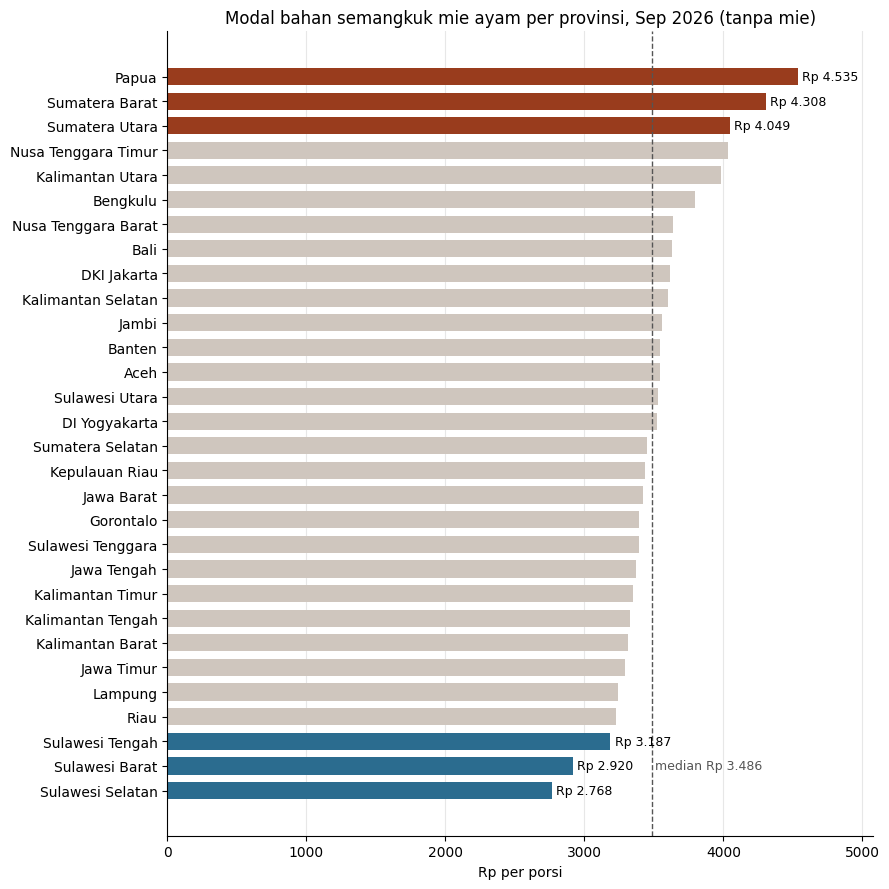

In [3]:
rp = lambda x: f"Rp {x:,.0f}".replace(',', '.')

urut = biaya.sort_values('total_tanpa_mie').reset_index(drop=True)  # termurah di indeks 0
n = len(urut)
med = urut['total_tanpa_mie'].median()
warna = ['#2B6C8F' if i < 3 else '#993C1D' if i >= n - 3 else '#CFC6BE' for i in range(n)]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(urut['provinsi'], urut['total_tanpa_mie'], color=warna, height=0.7)
ax.axvline(med, color='#555555', linestyle='--', linewidth=1)
ax.text(med + 25, 1, f'median {rp(med)}', va='center', fontsize=9, color='#555555')

for i, v in enumerate(urut['total_tanpa_mie']):
    if i < 3 or i >= n - 3:
        ax.text(v + 30, i, rp(v), va='center', fontsize=9)

ax.set_title('Modal bahan semangkuk mie ayam per provinsi, Sep 2026 (tanpa mie)')
ax.set_xlabel('Rp per porsi')
ax.set_xlim(0, urut['total_tanpa_mie'].max() * 1.12)
ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## Langkah 4: Bahan mana yang membedakan?

Biaya total adalah jumlah empat bahan. Pertanyaannya: perbedaan biaya antarprovinsi itu **paling banyak datang dari bahan yang mana**?

Caranya: untuk tiap bahan, hitung seberapa besar ia bergerak bersama total (kovarians) dibagi seberapa lebar total itu menyebar (varians). Hasilnya persentase peran tiap bahan, dan keempatnya jumlahnya 100%.

In [4]:
total = biaya['total_tanpa_mie']
peran = {b: 100 * biaya[b].cov(total) / total.var() for b in ['ayam', 'bawang_merah', 'bawang_putih', 'minyak']}
peran = pd.Series(peran).round(1)
print('Peran tiap bahan dalam perbedaan biaya antarprovinsi (%):')
print(peran.to_string())
print('Jumlah:', round(peran.sum(), 1))

Peran tiap bahan dalam perbedaan biaya antarprovinsi (%):
ayam            90.9
bawang_merah     4.7
bawang_putih     2.2
minyak           2.2
Jumlah: 100.0


**Cara membacanya:** ayam bukan hanya yang paling mahal di tiap porsi, harganya juga yang paling berbeda antarprovinsi. Bawang dan minyak harganya relatif mirip di mana-mana, jadi hampir tidak membedakan. Satu pengecualian menarik adalah Papua: bawang merahnya hampir dua kali nasional, itu yang membuatnya melewati Sumatera Barat.

In [5]:
koma = lambda x: f"{x:.1f}".replace('.', ',')
mahal, murah = urut.iloc[-1], urut.iloc[0]
selisih = mahal['total_tanpa_mie'] - murah['total_tanpa_mie']
persen = 100 * (mahal['total_tanpa_mie'] / murah['total_tanpa_mie'] - 1)

display(Markdown(f"""
## Kesimpulan kecil

- Modal bahan termahal ada di **{mahal['provinsi']}** ({rp(mahal['total_tanpa_mie'])}), termurah di **{murah['provinsi']}** ({rp(murah['total_tanpa_mie'])}). Selisihnya **{rp(selisih)}** per porsi, atau **{koma(persen)}%**.
- Sekitar **{koma(peran['ayam'])}%** dari perbedaan antarprovinsi datang dari harga ayam. Bawang dan minyak hampir tidak membedakan.
- Batasan: satu bulan (rata-rata hari kerja Sep 2026), 30 provinsi (empat dikeluarkan karena data minyak kurang atau harga datar), terigu belum masuk, resep adalah asumsi, dan angka ini harga pasar tradisional, bukan harga jual.

**Next:** notebook 5, apakah modal naik menjelang Lebaran?
"""))


## Kesimpulan kecil

- Modal bahan termahal ada di **Papua** (Rp 4.535), termurah di **Sulawesi Selatan** (Rp 2.768). Selisihnya **Rp 1.766** per porsi, atau **63,8%**.
- Sekitar **90,9%** dari perbedaan antarprovinsi datang dari harga ayam. Bawang dan minyak hampir tidak membedakan.
- Batasan: satu bulan (rata-rata hari kerja Sep 2026), 30 provinsi (empat dikeluarkan karena data minyak kurang atau harga datar), terigu belum masuk, resep adalah asumsi, dan angka ini harga pasar tradisional, bukan harga jual.

**Next:** notebook 5, apakah modal naik menjelang Lebaran?
